In [103]:
import numpy as np
import matplotlib.pyplot as plt
from pmd_beamphysics.units import mec2, c_light
from pmd_beamphysics import ParticleGroup

In [108]:
data = np.loadtxt("./LCLSII_50pC_Gaussian15ps_202101_750um.zd")
z_scaling = 1.33

In [109]:
data

array([[ 3.2672035e-01,  2.2982275e-02],
       [-5.1269893e-01, -9.0106871e-03],
       [-3.6397222e-01,  7.5326355e-06],
       ...,
       [ 3.3985534e-01,  2.3181755e-02],
       [ 4.9962084e-01,  2.4085859e-02],
       [-5.3045915e-01, -9.8559960e-03]])

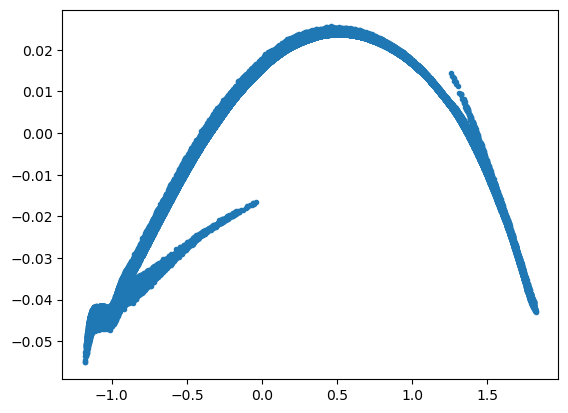

In [110]:
plt.plot(data[:, 0], data[:, 1], ".")

In [107]:
np.std(data[:, 0])

np.float64(0.7222842276314444)

In [91]:
data.shape

(200000, 2)

In [111]:
data[:, 0] *= z_scaling
data[:, 0] /= 1e3  # mm to m
data[:, 1] /= 100  # % to 1

In [112]:
energy = 100e6
gam0 = energy / mec2
gamma = gam0 * (1 + data[:, 1])
z = data[:, 0]
charge = 75e-12
weight = np.ones(z.shape) * charge / len(z)

In [113]:
len(z)

200000

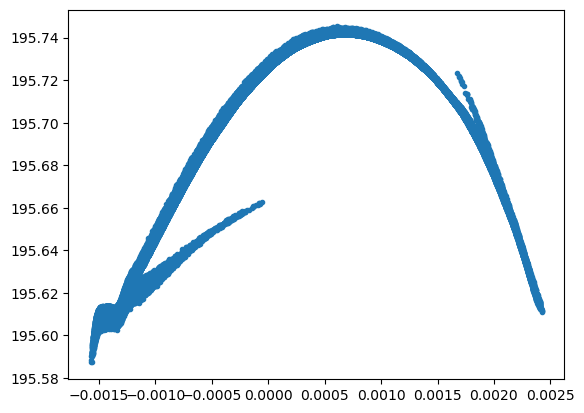

In [114]:
plt.plot(z, gamma, ".")

## Make Particle Group

In [8]:
n = len(z)
pz = np.sqrt(gamma**2 - 1) * mec2
particlegroup_data = dict(
    t=z / c_light,
    x=np.zeros(n),
    px=np.zeros(n),
    y=np.zeros(n),
    py=np.zeros(n),
    z=-z,
    pz=pz,
    weight=weight,
    status=np.ones(n),
    species="electron",
)
pg = ParticleGroup(data=particlegroup_data)

In [9]:
pg.write("from_Litrack_50pC.h5")

## Make BELT output format

In [115]:
z = -(z - np.mean(z))
delta_gamma = (gamma - gam0,)
delta_e_over_e0 = (gamma * mec2 - energy) / energy
BELT_data = np.vstack((z, delta_gamma, weight, delta_e_over_e0)).T
np.savetxt("./pts.in", BELT_data)

In [60]:
BELT_data.shape

(200000, 4)

In [56]:
0.2274e9 / 16.6 / 1e8

0.1369879518072289

In [57]:
0.0507e9 / 5.53 / 1e7

0.9168173598553344

In [85]:
dE_L2 = 1.5e9 - 2.5e8

In [86]:
dE_L2 / np.cos(-24.7 / 180 * np.pi) / 99.6 / 1e8

np.float64(0.13814075771314357)

In [22]:
dE_L3 = 4e9 - 1.5e9
dE_L3 / np.cos(0) / 166 / 1e8

np.float64(0.1506024096385542)

In [1]:
250 + 78 + 20 + 1719 + 778 + 130

2975

In [8]:
Lb = 0.549165215621
Ldb = 9.86910678674
angle = 0.046834318978504395

In [9]:
R56 = 2 * angle**2 * (Ldb + 2 / 3 * Lb)
print("R56 = ", R56)

R56 =  0.04490094345151552


In [7]:
import numpy as np

R56 = 0.045
angle = np.sqrt(R56 / (Ldb + 2 / 3 * Lb) / 2)
print("angle = ", angle)

angle =  0.04688595141399057
